In [1]:
import multiprocessing

from copy import deepcopy

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pickle
import seaborn as sns
import torch

from Figure_6B_utils import generalization_simple_complex_job
from src.network_parameters import network_parameters
from src.utils.general import get_signal_to_noise_ratio


from src.utils.plotting import (
    blue, blue_distribution, gray_dark as gray, green, orange, purple, yellow,
)

In [2]:
shared_num_seeds = 1
shared_seeds = list(range(shared_num_seeds))
shared_noise_levels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


network = torch.load("Data/checkpoints/network_3_B.pt", weights_only=False)
shared_snr_levels = [
    get_signal_to_noise_ratio(level, network, region="mtl_sensory")
    for level in shared_noise_levels
]


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:143: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())


## 6B. Effect of smeantic representations in Compositional Generalization

In [3]:
import os
import torch

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["MKL_DYNAMIC"] = "FALSE"
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
try:
    multiprocessing.set_start_method("fork")
except RuntimeError:
    pass

In [4]:
unified_input_params = {
    "num_days": 600,
    "day_length": 80,
    "mean_duration": 5,
    "fixed_duration": True,
    "num_swaps": 4,
}

unified_latent_specs = {
    "num": 2,
    "total_sizes": [50, 50],
    "act_sizes": [10, 10],
    "dims": [5, 5],
    "prob_list": [0.5 / 5 if i == j else 0.5 / 20 for i in range(5) for j in range(5)],
}

unified_num_cpu = 12
unified_seeds = shared_seeds
unified_noise_levels = shared_noise_levels
unified_network_modes = ["semantics_present", "semantics_absent", "semantics_random"]

unified_phase_A = 200
unified_phase_B = 400
unified_simple_train_days = 600
unified_simple_eval_days = 0
unified_complex_train_days = 400
unified_complex_eval_days = 100
unified_complex_train_chunk_days = 10
unified_use_full_mtl = False

unified_net_params = deepcopy(network_parameters)

unified_example_seed = unified_seeds[0]

unified_pretrain_num_swaps = 4
unified_record = False

In [5]:
generalization_simple_complex_experiment_params = [
    (
        network_mode,
        deepcopy(unified_net_params),
        deepcopy(unified_input_params),
        deepcopy(unified_latent_specs),
        int(num_swaps),
        int(seed),
        int(unified_pretrain_num_swaps),
        unified_phase_A,
        unified_phase_B,
        unified_simple_train_days,
        unified_simple_eval_days,
        unified_complex_train_days,
        unified_complex_eval_days,
        unified_complex_train_chunk_days,
        unified_use_full_mtl,
        bool(int(seed) == int(unified_example_seed)),
        bool(unified_record),
    )
    for seed in unified_seeds
    for network_mode in unified_network_modes
    for num_swaps in unified_noise_levels
]


In [6]:
with multiprocessing.Pool(processes=unified_num_cpu) as pool:
    generalization_simple_complex_job_results = pool.starmap(
        generalization_simple_complex_job,
        generalization_simple_complex_experiment_params,
    )

In [7]:
def aggregate_generalization_simple_complex_results(job_results, noise_levels=None, seeds=None, network_modes=None):
    if len(job_results) == 0:
        raise ValueError("job_results cannot be empty.")

    if noise_levels is None:
        noise_levels = sorted({int(job["num_swaps"]) for job in job_results})
    else:
        noise_levels = [int(level) for level in noise_levels]

    if seeds is None:
        seeds = sorted({int(job["seed"]) for job in job_results if job["seed"] is not None})
    else:
        seeds = [int(seed) for seed in seeds]

    if network_modes is None:
        network_modes = sorted({job["network_mode"] for job in job_results})

    aggregate = {
        "noise_levels": np.array(noise_levels, dtype=int),
        "seeds": seeds,
        "network_modes": list(network_modes),
        "raw_results": job_results,
        "summary": {},
        "example_networks": {network_mode: {} for network_mode in network_modes},
    }

    for network_mode in network_modes:
        mode_jobs = [job for job in job_results if job["network_mode"] == network_mode]
        simple_seed_curves = []
        complex_seed_curves = []
        replayed_awake_seed_curves = []
        replayed_replayed_seed_curves = []
        replayed_snr_seed_curves = []
        for seed in seeds:
            per_seed_jobs = [
                job for job in mode_jobs
                if int(job["seed"]) == int(seed)
            ]
            per_seed_jobs.sort(key=lambda job: int(job["num_swaps"]))
            if len(per_seed_jobs) != len(noise_levels):
                raise ValueError(
                    f"Missing jobs for network_mode={network_mode!r}, seed={seed}. "
                    f"Expected {len(noise_levels)} noise levels, got {len(per_seed_jobs)}."
                )
            for job in per_seed_jobs:
                if job.get("network") is not None:
                    aggregate["example_networks"][network_mode][int(job["num_swaps"])] = job["network"]
            simple_seed_curves.append(np.array([job["ctx_accuracy_mean"] for job in per_seed_jobs], dtype=float))
            complex_seed_curves.append(np.array([job["ctx_episode_accuracy"] for job in per_seed_jobs], dtype=float))
            replayed_awake_seed_curves.append(np.array([job["replayed_awake_generalization"] for job in per_seed_jobs], dtype=float))
            replayed_replayed_seed_curves.append(np.array([job["replayed_replayed_generalization"] for job in per_seed_jobs], dtype=float))
            replayed_snr_seed_curves.append(np.array([job["replayed_replayed_snr"] for job in per_seed_jobs], dtype=float))

        simple_seed_curves = np.stack(simple_seed_curves, axis=0)
        complex_seed_curves = np.stack(complex_seed_curves, axis=0)
        replayed_awake_seed_curves = np.stack(replayed_awake_seed_curves, axis=0)
        replayed_replayed_seed_curves = np.stack(replayed_replayed_seed_curves, axis=0)
        replayed_snr_seed_curves = np.stack(replayed_snr_seed_curves, axis=0)
        aggregate["summary"][network_mode] = {
            "simple_seed_curves": simple_seed_curves,
            "simple_mean_curve": simple_seed_curves.mean(axis=0),
            "simple_std_curve": simple_seed_curves.std(axis=0),
            "complex_seed_curves": complex_seed_curves,
            "complex_mean_curve": complex_seed_curves.mean(axis=0),
            "complex_std_curve": complex_seed_curves.std(axis=0),
            "replayed_awake_seed_curves": replayed_awake_seed_curves,
            "replayed_awake_mean_curve": replayed_awake_seed_curves.mean(axis=0),
            "replayed_awake_std_curve": replayed_awake_seed_curves.std(axis=0),
            "replayed_replayed_seed_curves": replayed_replayed_seed_curves,
            "replayed_replayed_mean_curve": replayed_replayed_seed_curves.mean(axis=0),
            "replayed_replayed_std_curve": replayed_replayed_seed_curves.std(axis=0),
            "replayed_snr_seed_curves": replayed_snr_seed_curves,
            "replayed_snr_mean_curve": replayed_snr_seed_curves.mean(axis=0),
            "replayed_snr_std_curve": replayed_snr_seed_curves.std(axis=0),
        }

    return aggregate

In [8]:
if "generalization_simple_complex_job_results" not in globals():
    raise NameError(
        "generalization_simple_complex_job_results is not defined. Run the simulation cell first."
    )

generalization_simple_complex_results = aggregate_generalization_simple_complex_results(
    generalization_simple_complex_job_results,
    noise_levels=unified_noise_levels,
    seeds=unified_seeds,
    network_modes=unified_network_modes,
)

with open("Data/fig_6B_generalization_simple_complex.pickle", "wb") as handle:
    pickle.dump(generalization_simple_complex_results, handle, protocol=pickle.HIGHEST_PROTOCOL)



/Users/albertalbesagonzalez/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [9]:
with open("Data/fig_6B_generalization_simple_complex.pickle", "rb") as handle:
    generalization_simple_complex_results = pickle.load(handle)

In [10]:
def plot_generalization_simple_complex_curve(results, curve_type, ax=None, ylabel="Accuracy", xlabel="SNR", x_values=None, xticklabels=None):
    if curve_type not in {"simple", "complex", "replayed_awake", "replayed_replayed"}:
        raise ValueError("curve_type must be 'simple', 'complex', 'replayed_awake', or 'replayed_replayed'.")

    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))

    colors = {
        "semantics_absent": orange,
        "semantics_random": gray,
        "semantics_present": green,
        "semantics_clean": green,
    }
    labels = {
        "semantics_absent": "semantics absent",
        "semantics_random": "semantics random",
        "semantics_present": "semantics present",
        "semantics_clean": "semantics clean",
    }

    x = results["noise_levels"] if x_values is None else np.asarray(x_values)
    for network_mode in results["network_modes"]:
        summary = results["summary"][network_mode]
        seed_curves = summary[f"{curve_type}_seed_curves"]
        mean_curve = summary[f"{curve_type}_mean_curve"]
        std_curve = summary[f"{curve_type}_std_curve"]
        color = colors[network_mode]
        for seed_curve in seed_curves:
            ax.scatter(x, seed_curve, color=color, alpha=0.35, s=24)
        ax.plot(x, mean_curve, color=color, linewidth=2.5, label=labels[network_mode])
        ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.15)

    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_xticks(x)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels)
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False, fontsize=16)
    return ax


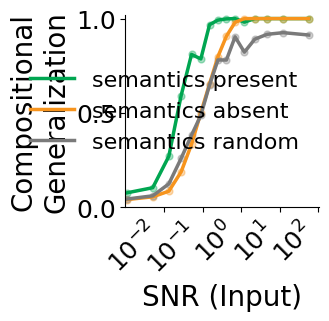

In [11]:
snr_values = np.asarray(shared_snr_levels, dtype=float)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
finite_snr_values = snr_values[finite_mask]
finite_noise_levels = np.asarray(shared_noise_levels, dtype=int)[finite_mask]

filtered_results = deepcopy(generalization_simple_complex_results)
filtered_results["noise_levels"] = finite_noise_levels
for network_mode in filtered_results["network_modes"]:
    summary = filtered_results["summary"][network_mode]
    summary["complex_seed_curves"] = summary["complex_seed_curves"][:, finite_mask]
    summary["complex_mean_curve"] = summary["complex_mean_curve"][finite_mask]
    summary["complex_std_curve"] = summary["complex_std_curve"][finite_mask]

fig, ax = plt.subplots(figsize=(2.5, 2.5))
plot_generalization_simple_complex_curve(
    filtered_results,
    curve_type="complex",
    ax=ax,
    ylabel="Compositional\nGeneralization",
    xlabel="SNR (Input)",
    x_values=finite_snr_values,
)
ax.set_xscale("log")
shared_lower = 1e-3
shared_upper = max(float(np.max(finite_snr_values)), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
sns.despine()
plt.savefig("Figures/SVG/6d.svg", dpi=300, transparent=True)
plt.show()



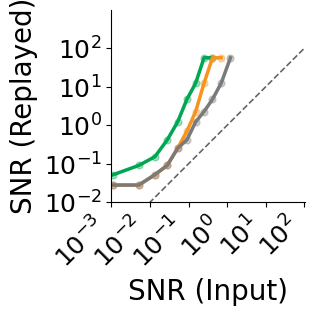

In [12]:
# Replay SNR is inferred from the replayed patterns used for the replayed/replayed test.
input_snr = np.asarray([dict(zip(shared_noise_levels, shared_snr_levels))[int(level)] for level in generalization_simple_complex_results["noise_levels"]], dtype=float)
valid_input = np.isfinite(input_snr) & (input_snr > 0)
if not valid_input.any():
    raise ValueError("No positive finite input SNR values are available for plotting.")

colors = {"semantics_absent": orange, "semantics_random": gray, "semantics_present": green, "semantics_clean": green}
fig, ax = plt.subplots(figsize=(2.5, 2.5))
positive_replayed_snr = []
for network_mode in generalization_simple_complex_results["network_modes"]:
    summary = generalization_simple_complex_results["summary"][network_mode]
    seed_curves = np.asarray(summary["replayed_snr_seed_curves"], dtype=float)[:, valid_input]
    mean_curve = np.asarray(summary["replayed_snr_mean_curve"], dtype=float)[valid_input]
    std_curve = np.asarray(summary["replayed_snr_std_curve"], dtype=float)[valid_input]
    x = input_snr[valid_input]
    color = colors[network_mode]
    for seed_curve in seed_curves:
        valid = np.isfinite(seed_curve) & (seed_curve > 0)
        ax.scatter(x[valid], seed_curve[valid], color=color, alpha=0.35, s=24)
    valid = np.isfinite(mean_curve) & (mean_curve > 0)
    ax.plot(x[valid], mean_curve[valid], color=color, linewidth=2.5)
    ax.fill_between(x[valid], np.maximum(mean_curve[valid] - std_curve[valid], np.finfo(float).tiny), mean_curve[valid] + std_curve[valid], color=color, alpha=0.15)
    positive_replayed_snr.extend(mean_curve[valid])

positive_replayed_snr = np.asarray(positive_replayed_snr, dtype=float)
if positive_replayed_snr.size == 0:
    raise ValueError("No positive finite replay SNR values are available for plotting.")

ax.set_xlabel("SNR (Input)", fontsize=20)
ax.set_ylabel("SNR (Replayed)", fontsize=20)
ax.set_xscale("log")
ax.set_yscale("log")
shared_lower = min(float(input_snr[valid_input].min()), float(positive_replayed_snr.min()), 1e-3)
shared_upper = max(float(input_snr[valid_input].max()), float(positive_replayed_snr.max()), 1e2)
identity = np.array([shared_lower, shared_upper])
ax.plot(identity, identity, linestyle="--", linewidth=1.2, color="black", alpha=0.6, zorder=0)
ticks = np.array([1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2])
ticks = ticks[(ticks >= shared_lower) & (ticks <= shared_upper)]
formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper * 1.05)
ax.set_ylim(shared_lower, shared_upper * 1.05)
ax.xaxis.set_major_locator(mticker.FixedLocator(ticks))
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
sns.despine()
plt.ylim([1e-2, 1e3])
plt.savefig("Figures/SVG/6e.svg", dpi=300, transparent=True)
plt.show()


In [13]:
# Replayed-to-awake generalization from the receptive fields above.
# Rerun the 6d simulations and aggregation cells after adding this metric.
replayed_awake_by_noise = {
    int(noise_level): float(snr)
    for noise_level, snr in zip(shared_noise_levels, shared_snr_levels)
}
snr_values = np.array(
    [replayed_awake_by_noise[int(level)] for level in generalization_simple_complex_results["noise_levels"]],
    dtype=float,
)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
if not finite_mask.any():
    raise ValueError("No positive finite SNR values are available for plotting.")

filtered_results = deepcopy(generalization_simple_complex_results)
filtered_results["noise_levels"] = np.asarray(filtered_results["noise_levels"])[finite_mask]
for summary in filtered_results["summary"].values():
    for key in [
        "replayed_awake_seed_curves",
        "replayed_awake_mean_curve",
        "replayed_awake_std_curve",
    ]:
        values = np.asarray(summary[key])
        summary[key] = values[:, finite_mask] if values.ndim == 2 else values[finite_mask]

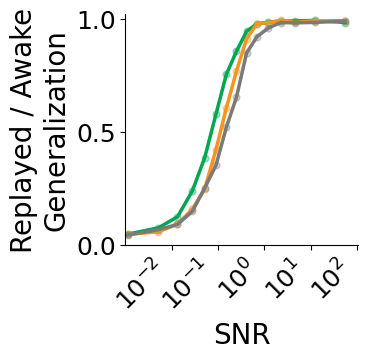

In [14]:
fig, ax = plt.subplots(figsize=(3, 3))
plot_generalization_simple_complex_curve(
    filtered_results,
    curve_type="replayed_awake",
    ax=ax,
    ylabel="Replayed / Awake\nGeneralization",
    xlabel="SNR",
    x_values=snr_values[finite_mask],
)

shared_lower = 1e-3
shared_upper = max(float(np.max(snr_values[finite_mask])), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xscale("log")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
legend_ = ax.get_legend()
if legend_ is not None:
    legend_.remove()
sns.despine()
plt.savefig("Figures/SVG/6f.svg", dpi=300, transparent=True)
plt.show()

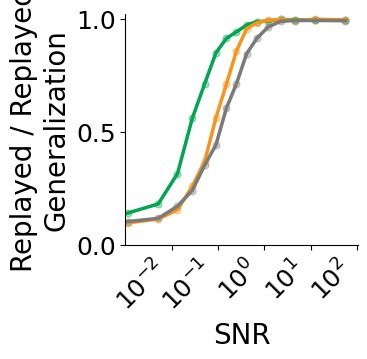

In [15]:
# Replayed-to-replayed generalization from independently sampled replay patterns.
# Rerun the 6d simulations and aggregation cells after adding this metric.
replayed_replayed_by_noise = {
    int(noise_level): float(snr)
    for noise_level, snr in zip(shared_noise_levels, shared_snr_levels)
}
snr_values = np.array(
    [replayed_replayed_by_noise[int(level)] for level in generalization_simple_complex_results["noise_levels"]],
    dtype=float,
)
finite_mask = np.isfinite(snr_values) & (snr_values > 0)
if not finite_mask.any():
    raise ValueError("No positive finite SNR values are available for plotting.")

filtered_results = deepcopy(generalization_simple_complex_results)
filtered_results["noise_levels"] = np.asarray(filtered_results["noise_levels"])[finite_mask]
for summary in filtered_results["summary"].values():
    for key in [
        "replayed_replayed_seed_curves",
        "replayed_replayed_mean_curve",
        "replayed_replayed_std_curve",
    ]:
        values = np.asarray(summary[key])
        summary[key] = values[:, finite_mask] if values.ndim == 2 else values[finite_mask]

fig, ax = plt.subplots(figsize=(3, 3))
plot_generalization_simple_complex_curve(
    filtered_results,
    curve_type="replayed_replayed",
    ax=ax,
    ylabel="Replayed / Replayed\nGeneralization",
    xlabel="SNR",
    x_values=snr_values[finite_mask],
)

shared_lower = 1e-3
shared_upper = max(float(np.max(snr_values[finite_mask])), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xscale("log")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
legend_ = ax.get_legend()
if legend_ is not None:
    legend_.remove()
sns.despine()
plt.savefig("Figures/SVG/6g.svg", dpi=300, transparent=True)
plt.show()


In [16]:
# Relate the new receptive-field generalization measures to test generalization.
# Each point is a (network mode, corruption level) mean across available seeds.

if "generalization_simple_complex_results" not in globals():
    with open("Data/fig_6B_generalization_simple_complex.pickle", "rb") as handle:
        generalization_simple_complex_results = pickle.load(handle)

common_networks = ["semantics_absent", "semantics_random", "semantics_present"]

def mean_by_network_and_noise(raw_results, value_key):
    grouped = {}
    for job in raw_results:
        network_mode = job["network_mode"]
        if network_mode not in common_networks:
            continue
        key = (network_mode, int(job["num_swaps"]))
        grouped.setdefault(key, []).append(float(job[value_key]))
    return {key: float(np.mean(values)) for key, values in grouped.items()}

raw_results = generalization_simple_complex_results["raw_results"]
test_generalization_by_key = mean_by_network_and_noise(
    raw_results, "ctx_episode_accuracy"
)
replayed_awake_by_key = mean_by_network_and_noise(
    raw_results, "replayed_awake_generalization"
)
replayed_replayed_by_key = mean_by_network_and_noise(
    raw_results, "replayed_replayed_generalization"
)

def aligned_measurements(measure_by_key):
    shared_keys = sorted(set(test_generalization_by_key) & set(measure_by_key))
    if len(shared_keys) < 2:
        raise ValueError(
            "At least two shared (network mode, corruption level) results are required. "
            "Rerun the unified Figure 6B simulations to generate the new metrics."
        )
    return (
        shared_keys,
        np.array([measure_by_key[key] for key in shared_keys], dtype=float),
        np.array([test_generalization_by_key[key] for key in shared_keys], dtype=float),
    )

def linear_fit_r2(x, y):
    if np.allclose(x, x[0]):
        return None, float("nan")
    coefficients = np.polyfit(x, y, deg=1)
    prediction = np.polyval(coefficients, x)
    total_variance = np.sum((y - y.mean()) ** 2)
    r_squared = float("nan") if np.isclose(total_variance, 0) else (
        1 - np.sum((y - prediction) ** 2) / total_variance
    )
    return coefficients, r_squared

keys_replayed_awake, x_replayed_awake, y_test_awake = aligned_measurements(replayed_awake_by_key)
keys_replayed_replayed, x_replayed_replayed, y_test_replayed = aligned_measurements(replayed_replayed_by_key)
replayed_awake_coef, replayed_awake_r2 = linear_fit_r2(
    x_replayed_awake, y_test_awake
)
replayed_replayed_coef, replayed_replayed_r2 = linear_fit_r2(
    x_replayed_replayed, y_test_replayed
)

print(f"Replayed/awake versus test points: {len(x_replayed_awake)}")
print(f"Replayed/replayed versus test points: {len(x_replayed_replayed)}")


Replayed/awake versus test points: 45
Replayed/replayed versus test points: 45


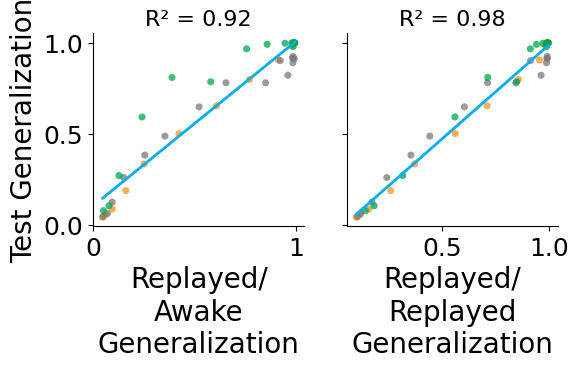

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)

scatter_kws = dict(s=26, alpha=0.75, edgecolors="none")
mode_colors = {
    "semantics_absent": orange,
    "semantics_random": gray,
    "semantics_present": green,
}
mode_labels = {
    "semantics_absent": "semantics absent",
    "semantics_random": "semantics random",
    "semantics_present": "semantics present",
}
trend_color = blue_distribution

plot_data = [
    (
        axes[0], keys_replayed_awake, x_replayed_awake, y_test_awake, replayed_awake_coef,
        replayed_awake_r2, "Replayed/\nAwake\nGeneralization",
    ),
    (
        axes[1], keys_replayed_replayed, x_replayed_replayed, y_test_replayed, replayed_replayed_coef,
        replayed_replayed_r2, "Replayed/\nReplayed\nGeneralization",
    ),
]

for ax, keys, x, y, coefficients, r_squared, xlabel in plot_data:
    for mode in common_networks:
        mask = np.array([key[0] == mode for key in keys], dtype=bool)
        ax.scatter(x[mask], y[mask], color=mode_colors[mode], label=mode_labels[mode], **scatter_kws)
    if coefficients is not None:
        xx = np.linspace(x.min(), x.max(), 200)
        ax.plot(xx, np.polyval(coefficients, xx), color=trend_color, linewidth=2)
    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_title(f"R² = {r_squared:.2f}", fontsize=16)
    ax.tick_params(labelsize=18)
    sns.despine(ax=ax)

axes[0].set_ylabel("Test Generalization", fontsize=20)
axes[1].tick_params(labelleft=False)
handles, labels = axes[1].get_legend_handles_labels()

plt.savefig(
    "Figures/SVG/S6a.svg",
    dpi=300,
    transparent=True,
)
plt.show()
